# Level 3 — Task 3
### Neural Networks with TensorFlow/Keras

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score, classification_report
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

In [2]:
df = pd.read_csv("iris.csv")
print(df.head())

   Id  SepalLengthCm  SepalWidthCm  PetalLengthCm  PetalWidthCm      Species
0   1            5.1           3.5            1.4           0.2  Iris-setosa
1   2            4.9           3.0            1.4           0.2  Iris-setosa
2   3            4.7           3.2            1.3           0.2  Iris-setosa
3   4            4.6           3.1            1.5           0.2  Iris-setosa
4   5            5.0           3.6            1.4           0.2  Iris-setosa


In [3]:
print("Shape:", df.shape)
print("\nColumns:")
print(df.columns)
print("\nMissing Values:")
print(df.isnull().sum())
print("\nDataset Information:")
df.info()

Shape: (150, 6)

Columns:
Index(['Id', 'SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm',
       'Species'],
      dtype='object')

Missing Values:
Id               0
SepalLengthCm    0
SepalWidthCm     0
PetalLengthCm    0
PetalWidthCm     0
Species          0
dtype: int64

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             150 non-null    int64  
 1   SepalLengthCm  150 non-null    float64
 2   SepalWidthCm   150 non-null    float64
 3   PetalLengthCm  150 non-null    float64
 4   PetalWidthCm   150 non-null    float64
 5   Species        150 non-null    object 
dtypes: float64(4), int64(1), object(1)
memory usage: 7.2+ KB


In [4]:
X = df.drop(["Id","Species"], axis=1)
y = df["Species"]
print("Features:")
print(X.head())
print("\nTarget:")
print(y.head())

Features:
   SepalLengthCm  SepalWidthCm  PetalLengthCm  PetalWidthCm
0            5.1           3.5            1.4           0.2
1            4.9           3.0            1.4           0.2
2            4.7           3.2            1.3           0.2
3            4.6           3.1            1.5           0.2
4            5.0           3.6            1.4           0.2

Target:
0    Iris-setosa
1    Iris-setosa
2    Iris-setosa
3    Iris-setosa
4    Iris-setosa
Name: Species, dtype: object


In [5]:
encoder = LabelEncoder()
y = encoder.fit_transform(y)
print("Classes:")
print(encoder.classes_)
print("Encoded Target:")
print(y[:10])

Classes:
['Iris-setosa' 'Iris-versicolor' 'Iris-virginica']
Encoded Target:
[0 0 0 0 0 0 0 0 0 0]


In [6]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.20,random_state=42,stratify=y)
print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (120, 4)
Testing data: (30, 4)


In [7]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)
print("Feature scaling completed.")

Feature scaling completed.


In [8]:
model = Sequential([
    Dense(16, activation="relu", input_shape=(4,)),
    Dense(8, activation="relu"),
    Dense(3, activation="softmax")
])
model.summary()

C:\Users\udayb\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (None, 16)                  │              80 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 8)                   │             136 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 3)                   │              27 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 243 (972.00 B)

 Trainable params: 243 (972.00 B)

 Non-trainable params: 0 (0.00 B)

In [9]:
model.compile(optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [10]:
history = model.fit(X_train,y_train,epochs=50,batch_size=8,validation_split=0.20,verbose=1)

Epoch 1/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 3s 52ms/step - accuracy: 0.2708 - loss: 1.1267 - val_accuracy: 0.2500 - val_loss: 1.0966
Epoch 2/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.3750 - loss: 1.0462 - val_accuracy: 0.5833 - val_loss: 1.0336
Epoch 3/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.6354 - loss: 0.9830 - val_accuracy: 0.5833 - val_loss: 0.9850
Epoch 4/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.6458 - loss: 0.9338 - val_accuracy: 0.6250 - val_loss: 0.9516
Epoch 5/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.6667 - loss: 0.8893 - val_accuracy: 0.6250 - val_loss: 0.9227
Epoch 6/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.7083 - loss: 0.8505 - val_accuracy: 0.6250 - val_loss: 0.8955
Epoch 7/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.7188 - loss: 0.8132 - val_accuracy: 0.6250 - val_loss: 0.8687
Epoch 8/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.7188 - loss: 0.7787 - val_accuracy: 0.6667 - va

In [11]:
loss, accuracy = model.evaluate(
    X_test,
    y_test,
    verbose=0
)
print("Test Loss:", loss)
print("Test Accuracy:", accuracy)

Test Loss: 0.2013099044561386
Test Accuracy: 0.9333333373069763


In [12]:
predictions = model.predict(X_test)
y_pred = np.argmax(predictions,axis=1)
print("Predicted Classes:")
print(y_pred)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 126ms/step
Predicted Classes:
[0 2 1 1 0 2 0 0 2 1 2 2 2 1 0 0 0 1 1 2 0 2 1 2 2 2 1 0 2 0]


In [13]:
accuracy = accuracy_score(y_test,y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.9333333333333333


In [14]:
print(classification_report(y_test,y_pred,target_names=encoder.classes_))

                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        10
Iris-versicolor       1.00      0.80      0.89        10
 Iris-virginica       0.83      1.00      0.91        10

       accuracy                           0.93        30
      macro avg       0.94      0.93      0.93        30
   weighted avg       0.94      0.93      0.93        30



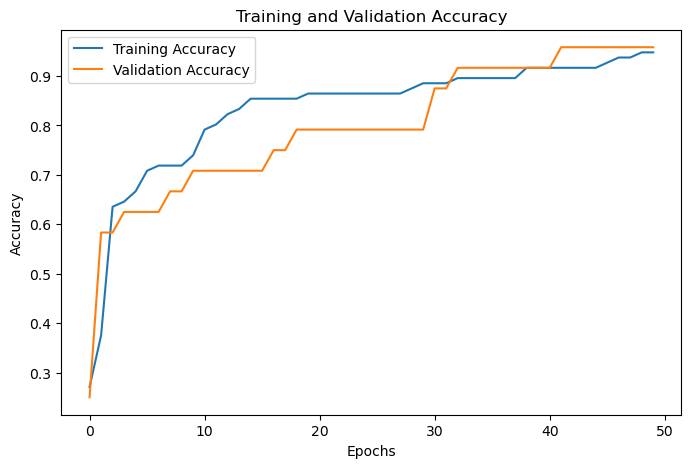

In [15]:
plt.figure(figsize=(8, 5))
plt.plot(history.history["accuracy"],label="Training Accuracy")
plt.plot(history.history["val_accuracy"],label="Validation Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.title("Training and Validation Accuracy")
plt.legend()
plt.show()

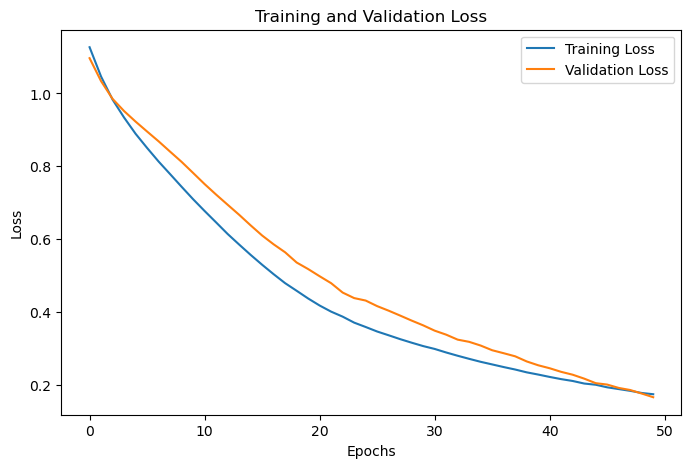

In [16]:
plt.figure(figsize=(8, 5))
plt.plot(history.history["loss"],label="Training Loss")
plt.plot(history.history["val_loss"],label="Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.legend()
plt.show()

In [17]:
tuned_model = Sequential([
    Dense(32, activation="relu", input_shape=(4,)),
    Dense(16, activation="relu"),
    Dense(3, activation="softmax")
])
tuned_model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

C:\Users\udayb\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [18]:
tuned_history = tuned_model.fit(X_train,y_train,epochs=50,batch_size=8,validation_split=0.20,verbose=1)

Epoch 1/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 2s 33ms/step - accuracy: 0.4271 - loss: 1.0536 - val_accuracy: 0.6250 - val_loss: 0.9687
Epoch 2/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.6979 - loss: 0.9107 - val_accuracy: 0.6667 - val_loss: 0.8542
Epoch 3/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.7812 - loss: 0.7880 - val_accuracy: 0.6250 - val_loss: 0.7599
Epoch 4/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.7812 - loss: 0.6908 - val_accuracy: 0.6667 - val_loss: 0.6815
Epoch 5/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.8125 - loss: 0.6082 - val_accuracy: 0.6667 - val_loss: 0.6239
Epoch 6/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.8229 - loss: 0.5478 - val_accuracy: 0.6250 - val_loss: 0.5802
Epoch 7/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.8229 - loss: 0.4974 - val_accuracy: 0.6667 - val_loss: 0.5461
Epoch 8/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.8333 - loss: 0.4602 - val_accuracy: 0.7083 - va

In [19]:
tuned_loss, tuned_accuracy = tuned_model.evaluate(X_test,y_test,verbose=0)
print("Tuned Model Loss:", tuned_loss)
print("Tuned Model Accuracy:", tuned_accuracy)

Tuned Model Loss: 0.13920840620994568
Tuned Model Accuracy: 0.9333333373069763


In [20]:
print("Original Model Accuracy:", accuracy)
print("Tuned Model Accuracy:", tuned_accuracy)
if tuned_accuracy > accuracy:
    print("Tuned model performs better.")
else:
    print("Original model performs better.")

Original Model Accuracy: 0.9333333333333333
Tuned Model Accuracy: 0.9333333373069763
Tuned model performs better.
